# 04 — ToxNet Training with Focal Loss + OPTUNA

**Phase 4 of plan.md**

This notebook:
1. Loads featurized data with scaffold split
2. Trains ToxNet (multi-task neural network) with Focal Loss
3. Uses OPTUNA to find optimal hyperparameters
4. Saves the best model to `models/toxnet_final.pt`

In [1]:
import sys
import os
# Change working directory to project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import torch
import numpy as np
import matplotlib.pyplot as plt
from src.featurize import TARGET_COLS
from src.model import ToxNet
from src.train import prepare_data, train_model, run_optuna_search

In [2]:
# Prepare data (load, featurize, scaffold split)
X_train, Y_train, X_val, Y_val, X_test, Y_test, pos_weights = prepare_data()

Raw dataset: 8014 compounds, 14 columns


[16:49:28] WARNING: not removing hydrogen atom without neighbors
[16:49:29] Explicit valence for atom # 8 Al, 6, is greater than permitted


[16:49:29] Explicit valence for atom # 3 Al, 6, is greater than permitted
[16:49:29] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:49:29] Explicit valence for atom # 4 Al, 6, is greater than permitted


[16:49:29] Explicit valence for atom # 9 Al, 6, is greater than permitted
[16:49:29] Explicit valence for atom # 5 Al, 6, is greater than permitted
[16:49:29] Explicit valence for atom # 16 Al, 6, is greater than permitted
[16:49:29] Explicit valence for atom # 20 Al, 6, is greater than permitted


  Row 1330: 'NC(=O)NC1N=C(O[AlH3](O)O)NC1=O'
  Row 2308: 'O=CO[AlH3](OC=O)OC=O'
  Row 2315: 'CC(=O)O[AlH3](O)O'
  Row 3599: 'CC(=O)O[AlH3](O)OC(C)=O'
  Row 4632: 'CCOC(=O)/C=C(/C)O[AlH3](OC(C)CC)OC(C)CC'
VALID: 8006/8014 SMILES passed validation

Cleaned dataset: 8006 compounds

Per-endpoint toxic prevalence:
  NR-AR                 toxic= 309/7432  (  4.2%)  NaN=7%
  NR-AR-LBD             toxic= 238/6895  (  3.5%)  NaN=14%
  NR-AhR                toxic= 785/6684  ( 11.7%)  NaN=17%
  NR-Aromatase          toxic= 307/5934  (  5.2%)  NaN=26%
  NR-ER                 toxic= 796/6309  ( 12.6%)  NaN=21%
  NR-ER-LBD             toxic= 355/7105  (  5.0%)  NaN=11%
  NR-PPAR-gamma         toxic= 189/6576  (  2.9%)  NaN=18%
  SR-ARE                toxic= 961/5928  ( 16.2%)  NaN=26%
  SR-ATAD5              toxic= 267/7225  (  3.7%)  NaN=10%
  SR-HSE                toxic= 379/6587  (  5.8%)  NaN=18%
  SR-MMP                toxic= 936/5914  ( 15.8%)  NaN=26%
  SR-p53                toxic= 431/6902  

...

[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerat

[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerat

[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerator
[16:49:38] DEPRECATION WARNING: please use MorganGenerat

Per-endpoint positive weights (n_neg / n_pos):
  NR-AR                 weight=22.8
  NR-AR-LBD             weight=27.8
  NR-AhR                weight=8.1
  NR-Aromatase          weight=21.5
  NR-ER                 weight=7.0
  NR-ER-LBD             weight=18.3
  NR-PPAR-gamma         weight=39.5
  SR-ARE                weight=5.8
  SR-ATAD5              weight=28.3
  SR-HSE                weight=17.6
  SR-MMP                weight=5.7
  SR-p53                weight=18.2

Data prepared:
  Train: (6404, 2048)
  Val:   (800, 2048)
  Test:  (802, 2048)


[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerator
[16:49:39] DEPRECATION WARNING: please use MorganGenerat

## 1. ToxNet Architecture

```
Input (2048) → Shared Backbone [1024→512→256] → 12 Task Heads [256→64→1]
```

- Shared backbone learns common chemistry patterns
- Each head specializes in one toxicity endpoint

In [3]:
# Show model architecture
model = ToxNet(input_dim=2048)
total_params = sum(p.numel() for p in model.parameters())
print(f"ToxNet Architecture:")
print(f"  Total parameters: {total_params:,}")
print(f"  Input: 2048 (ECFP4 fingerprint)")
print(f"  Output: 12 (one per Tox21 endpoint)")
print(f"\nArchitecture:\n{model}")

ToxNet Architecture:
  Total parameters: 2,956,044
  Input: 2048 (ECFP4 fingerprint)
  Output: 12 (one per Tox21 endpoint)

Architecture:
ToxNet(
  (backbone): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.3, inplace=False)
  )
  (heads): ModuleList(
    (0-11): 12 x Sequential(
      (0): Linear(in_features=256, out_features=64, bias=True)
      (1): ReLU()
      (2):

## 2. Quick Training (Default Hyperparameters)

First, a quick 20-epoch training to verify everything works.

In [4]:
# Quick training (20 epochs)
print("Training ToxNet (20 epochs, default params)...")
model, val_auprc, history = train_model(
    X_train, Y_train, X_val, Y_val, pos_weights,
    n_epochs=20, patience=10, verbose=True,
)
print(f"\nQuick training result: val AUPRC = {val_auprc:.4f}")

Training ToxNet (20 epochs, default params)...


  Epoch   5  loss=0.1189  val_AUPRC=0.2764  best=0.3021


  Epoch  10  loss=0.0587  val_AUPRC=0.2895  best=0.3037


  Epoch  15  loss=0.0894  val_AUPRC=0.2979  best=0.3037


  Early stopping at epoch 18

Quick training result: val AUPRC = 0.3037


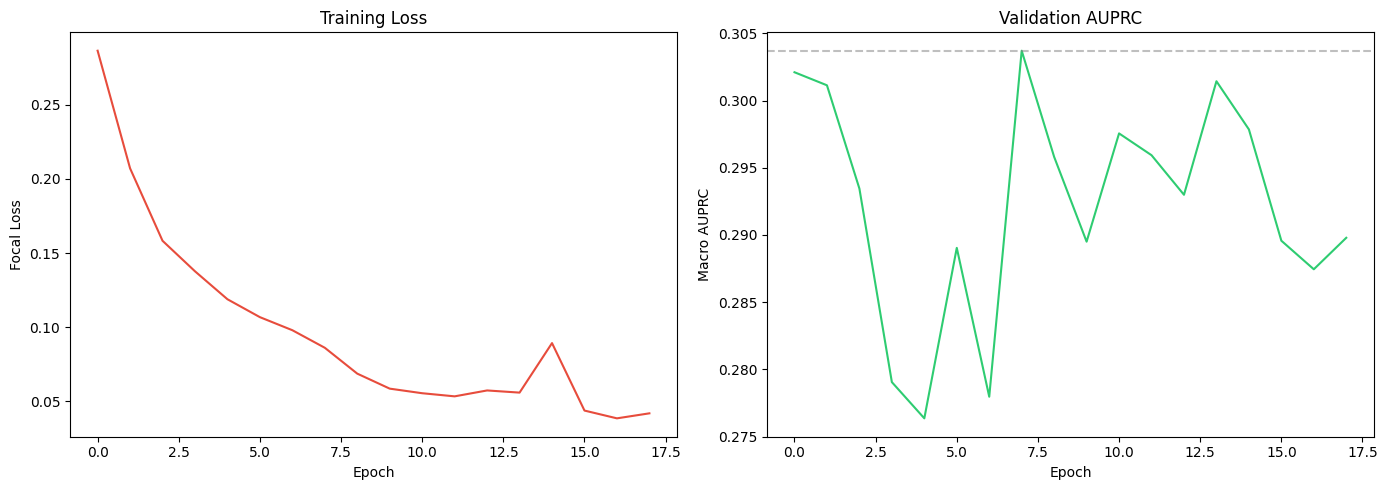

Saved: notebooks/04_training_history.png


In [5]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], color='#e74c3c')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].set_title('Training Loss')

axes[1].plot(history['val_auprc'], color='#2ecc71')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro AUPRC')
axes[1].set_title('Validation AUPRC')
axes[1].axhline(y=max(history['val_auprc']), color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('notebooks/04_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: notebooks/04_training_history.png")

## 3. OPTUNA Hyperparameter Search

Tuning: lr, dropout, batch_size, focal_gamma, hidden_dims, weight_decay

Set n_trials=50 for full search, or n_trials=10 for a quick test.

In [6]:
# OPTUNA search (set n_trials=50 for full run, 10 for quick test)
N_TRIALS = 10  # Change to 50 for full search

best_params = run_optuna_search(
    X_train, Y_train, X_val, Y_val, pos_weights,
    n_trials=N_TRIALS,
)
print(f"\nBest params: {best_params}")

[I 2026-04-26 16:50:49,765] A new study created in memory with name: no-name-6cd2f09e-5529-49bc-ad25-beadafa0bd95



Starting OPTUNA search (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-26 16:51:20,770] Trial 0 finished with value: 0.29440343237548655 and parameters: {'lr': 0.0018714294615950202, 'dropout': 0.2077899055666521, 'batch_size': 256, 'gamma': 2.410272624769695, 'weight_decay': 0.000517063598676493, 'hidden_dims': 'large'}. Best is trial 0 with value: 0.29440343237548655.


[I 2026-04-26 16:51:38,056] Trial 1 finished with value: 0.29984582501402074 and parameters: {'lr': 0.005591117188703347, 'dropout': 0.17032940562639376, 'batch_size': 256, 'gamma': 2.880731389178611, 'weight_decay': 0.0003267702237013028, 'hidden_dims': 'small'}. Best is trial 1 with value: 0.29984582501402074.


...

[I 2026-04-26 16:57:03,594] Trial 5 finished with value: 0.31887811929650883 and parameters: {'lr': 0.00016910173150893137, 'dropout': 0.24269751370447362, 'batch_size': 128, 'gamma': 1.4935417070886978, 'weight_decay': 0.000270017385666092, 'hidden_dims': 'small'}. Best is trial 5 with value: 0.31887811929650883.


[I 2026-04-26 16:57:59,718] Trial 6 finished with value: 0.30920561417338194 and parameters: {'lr': 0.0002107459981281361, 'dropout': 0.19169869105897544, 'batch_size': 64, 'gamma': 1.7600710785992806, 'weight_decay': 0.0007390032273342019, 'hidden_dims': 'large'}. Best is trial 5 with value: 0.31887811929650883.


[I 2026-04-26 16:58:36,733] Trial 7 finished with value: 0.2831043552975463 and parameters: {'lr': 0.006821719344986871, 'dropout': 0.27774866750674676, 'batch_size': 64, 'gamma': 2.6549533660531015, 'weight_decay': 3.3278943658970954e-05, 'hidden_dims': 'small'}. Best is trial 5 with value: 0.31887811929650883.


[I 2026-04-26 16:59:42,819] Trial 8 finished with value: 0.2926951507999113 and parameters: {'lr': 0.0010630051025180473, 'dropout': 0.12662593070992748, 'batch_size': 64, 'gamma': 1.4636430107965936, 'weight_decay': 1.3093426956822881e-05, 'hidden_dims': 'small'}. Best is trial 5 with value: 0.31887811929650883.


[I 2026-04-26 17:00:18,403] Trial 9 finished with value: 0.28766959451049723 and parameters: {'lr': 0.002334641761214609, 'dropout': 0.1819995259709456, 'batch_size': 256, 'gamma': 1.4086744769853052, 'weight_decay': 8.163879842834557e-05, 'hidden_dims': 'medium'}. Best is trial 5 with value: 0.31887811929650883.

Best trial:
  Val AUPRC: 0.3189
  Params: {'lr': 0.00016910173150893137, 'dropout': 0.24269751370447362, 'batch_size': 128, 'gamma': 1.4935417070886978, 'weight_decay': 0.000270017385666092, 'hidden_dims': 'small'}

Best params: {'lr': 0.00016910173150893137, 'dropout': 0.24269751370447362, 'batch_size': 128, 'gamma': 1.4935417070886978, 'weight_decay': 0.000270017385666092, 'hidden_dims': 'small'}


## 4. Final Training with Best Parameters

In [7]:
# Train with best params
hidden_dims = {
    'small': [512, 256, 128],
    'medium': [1024, 512, 256],
    'large': [1024, 512, 512, 256],
}[best_params['hidden_dims']]

print("Training with OPTUNA-optimized parameters...")
model_final, final_auprc, final_history = train_model(
    X_train, Y_train, X_val, Y_val, pos_weights,
    lr=best_params['lr'],
    dropout=best_params['dropout'],
    batch_size=best_params['batch_size'],
    gamma=best_params['gamma'],
    hidden_dims=hidden_dims,
    weight_decay=best_params['weight_decay'],
    n_epochs=50,
    patience=15,
    verbose=True,
)

print(f"\nFinal val AUPRC: {final_auprc:.4f}")

Training with OPTUNA-optimized parameters...


  Epoch   5  loss=0.2578  val_AUPRC=0.3046  best=0.3050


  Epoch  10  loss=0.1371  val_AUPRC=0.2870  best=0.3050


  Epoch  15  loss=0.1110  val_AUPRC=0.2854  best=0.3050


  Early stopping at epoch 19

Final val AUPRC: 0.3050


Model saved to models/toxnet_final.pt


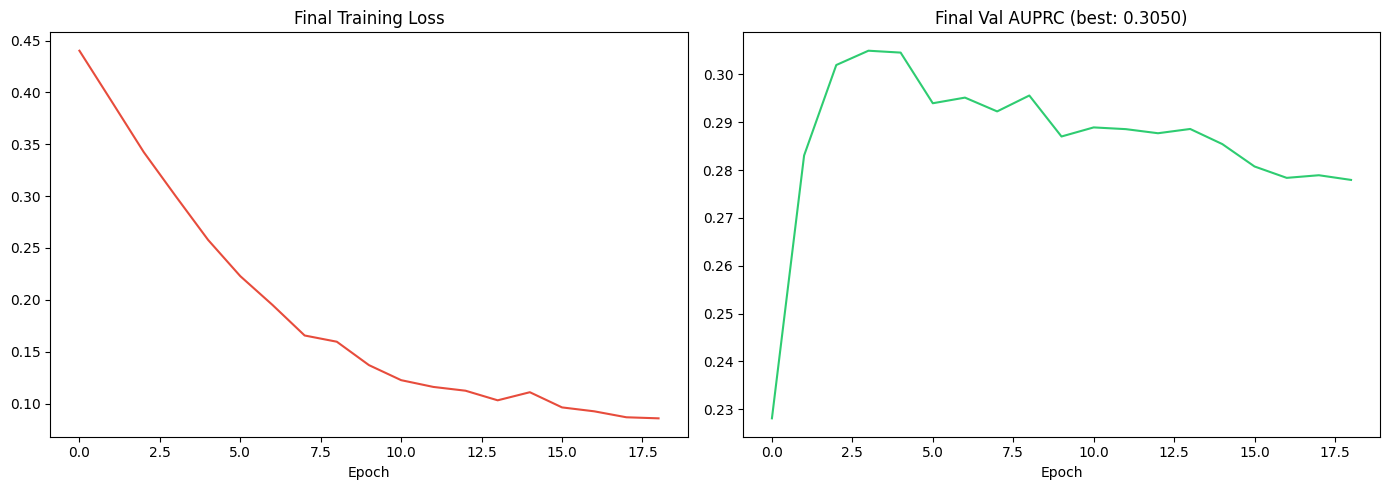

In [8]:
# Save final model
import os
os.makedirs('models', exist_ok=True)
torch.save(model_final.state_dict(), 'models/toxnet_final.pt')
print("Model saved to models/toxnet_final.pt")

# Plot final training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(final_history['train_loss'], color='#e74c3c')
axes[0].set_title('Final Training Loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(final_history['val_auprc'], color='#2ecc71')
axes[1].set_title(f'Final Val AUPRC (best: {final_auprc:.4f})')
axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('notebooks/04_final_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary

| Metric | Value |
|--------|-------|
| Quick Training AUPRC | see above |
| OPTUNA-Optimized AUPRC | see above |
| Target (plan.md) | 0.42 - 0.52 |